In [12]:
#Task 1 Data Understanding

In [13]:
import pandas as pd

data = pd.read_csv("Housing.csv")

data.head()
print("Shape:", data.shape)
data.info()

Shape: (545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
#TASK 2: Data Cleaning

In [2]:
# Clean column names
data.columns = data.columns.str.strip().str.lower()

# Check missing values
print(data.isnull().sum())

# Fill missing values
data = data.fillna(data.mean(numeric_only=True))

# Remove duplicates
data.drop_duplicates(inplace=True)

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [ ]:
#TASK 3: EDA

In [3]:
# Summary
data.describe()

# Average price by bedrooms
data.groupby('bedrooms')['price'].mean()

# Correlation
data.corr(numeric_only=True)

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


In [ ]:
TASK 4: Visualization

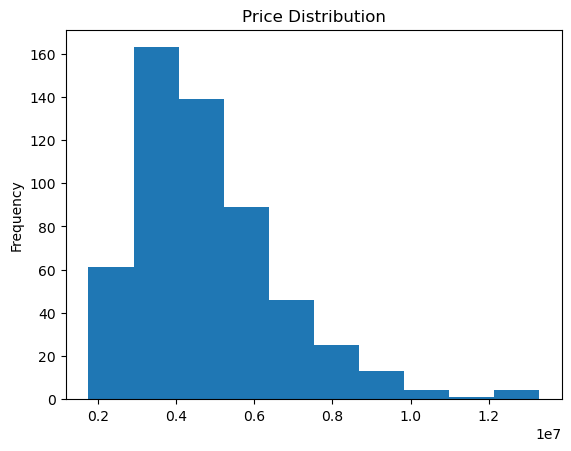

In [14]:
import matplotlib.pyplot as plt

# Price distribution
data['price'].plot(kind='hist')
plt.title("Price Distribution")
plt.show()



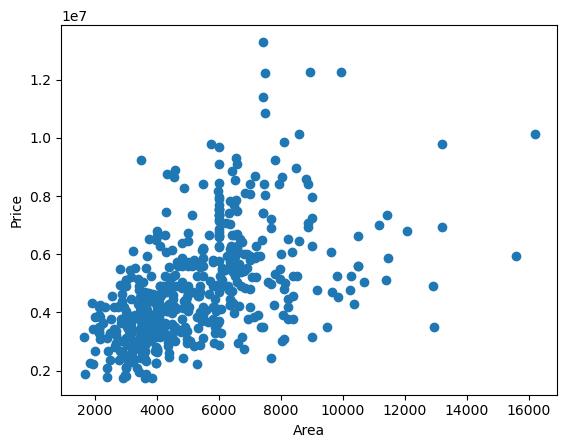

In [15]:
# Area vs Price
plt.scatter(data['area'], data['price'])
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()


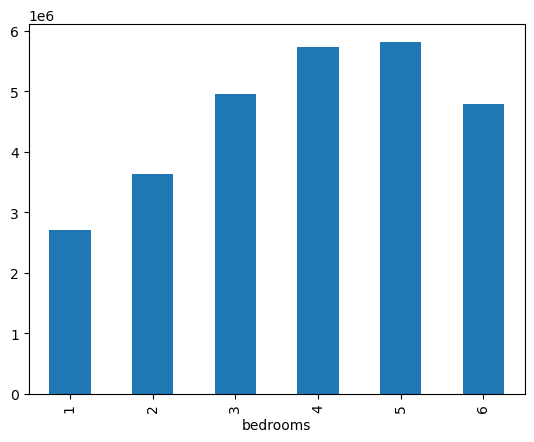

In [16]:

# Bedrooms vs Price
data.groupby('bedrooms')['price'].mean().plot(kind='bar')
plt.show()

In [17]:
#TASK 5: Predictive Modeling

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [6]:
X = data[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']]
y = data['price']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
y_pred = model.predict(X_test)

In [10]:
print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 1127483.3523235186
